# 13 — Notch / band-stop (`math`, SciPy, PyTorch, python-control)

**Baseline:** the analog notch (inverse of the band-pass in notebook `11`)

$$
H(s) = \frac{s^2 + \omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}
$$

A mix of 220 Hz + 880 Hz goes in; the notch is tuned to **880 Hz**. The fundamental should survive on every stack.

In [1]:
from __future__ import annotations

import math
import time

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")
if device.type == "cuda":
    print(f"CUDA {torch.version.cuda}  |  {torch.cuda.get_device_name(0)}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda
CUDA 13.2  |  NVIDIA GeForce RTX 3060


In [2]:
def bode_mag_phase(sys, omega):
    frd = ct.frequency_response(sys, omega=omega)
    if hasattr(frd, "magnitude"):
        w = np.asarray(frd.frequency).reshape(-1)
        m = np.asarray(frd.magnitude).reshape(-1)
        p = np.asarray(frd.phase).reshape(-1)
    else:
        mag, phase, om = frd
        w = np.asarray(om).reshape(-1)
        m = np.asarray(mag).reshape(-1)
        p = np.asarray(phase).reshape(-1)
    return w, m, p


def plot_bode(sys, title, marks=()):
    w, m, p = bode_mag_phase(sys, np.logspace(0, 5, 500))
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
    axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p)))
    for f, lab in marks:
        axes[0].axvline(f, color="k", ls="--", lw=1, label=lab)
        axes[1].axvline(f, color="k", ls="--", lw=1)
    axes[0].set_ylabel("mag (dB)")
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_xlabel("frequency (Hz)")
    for ax in axes:
        ax.grid(True, which="both", alpha=0.3)
    if marks:
        axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return w, m, p


def max_abs(a, b) -> float:
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))


In [3]:
FS_HZ = 8_192
DURATION_S = 0.12
FN_HZ = 880.0
ZETA = 0.08
F_KEEP = 220.0
F_KILL = 880.0
N = int(FS_HZ * DURATION_S)
DT = 1.0 / FS_HZ
WN = 2.0 * math.pi * FN_HZ

t = np.arange(N, dtype=np.float64) / FS_HZ
u_keep = signal.square(2.0 * np.pi * F_KEEP * t)
u_kill = signal.square(2.0 * np.pi * F_KILL * t)
u_mix = 0.5 * u_keep + 0.5 * u_kill
print(f"fn = {FN_HZ} Hz   ζ = {ZETA}   Q ≈ {1.0 / (2.0 * ZETA):.2f}   device = {device}")

fn = 880.0 Hz   ζ = 0.08   Q ≈ 6.25   device = cuda


## python-control — \(H(s)\), Bode, three forced responses

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       s^2 + 3.057e+07
  -------------------------
  s^2 + 884.7 s + 3.057e+07


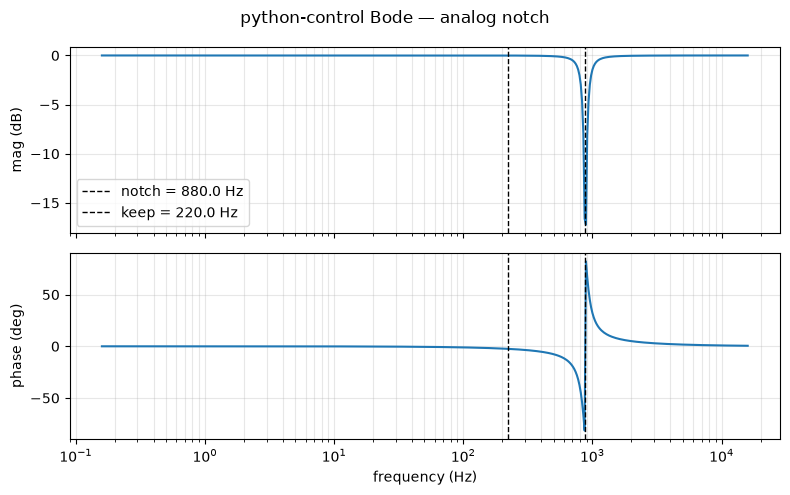

(array([1.00000000e+00, 1.02334021e+00, 1.04722519e+00, 1.07166765e+00,
        1.09668060e+00, 1.12227736e+00, 1.14847155e+00, 1.17527712e+00,
        1.20270833e+00, 1.23077980e+00, 1.25950646e+00, 1.28890361e+00,
        1.31898690e+00, 1.34977233e+00, 1.38127630e+00, 1.41351558e+00,
        1.44650734e+00, 1.48026913e+00, 1.51481892e+00, 1.55017512e+00,
        1.58635653e+00, 1.62338243e+00, 1.66127252e+00, 1.70004698e+00,
        1.73972643e+00, 1.78033202e+00, 1.82188534e+00, 1.86440853e+00,
        1.90792422e+00, 1.95245558e+00, 1.99802631e+00, 2.04466067e+00,
        2.09238348e+00, 2.14122015e+00, 2.19119669e+00, 2.24233968e+00,
        2.29467637e+00, 2.34823460e+00, 2.40304289e+00, 2.45913043e+00,
        2.51652705e+00, 2.57526333e+00, 2.63537052e+00, 2.69688063e+00,
        2.75982639e+00, 2.82424133e+00, 2.89015972e+00, 2.95761666e+00,
        3.02664806e+00, 3.09729067e+00, 3.16958209e+00, 3.24356081e+00,
        3.31926620e+00, 3.39673858e+00, 3.47601918e+00, 3.557150

In [4]:
sys_n = ct.tf([1.0, 0.0, WN**2], [1.0, 2.0 * ZETA * WN, WN**2])
print(sys_n)
_, y_ct_keep = ct.forced_response(sys_n, T=t, U=u_keep)
_, y_ct_kill = ct.forced_response(sys_n, T=t, U=u_kill)
_, y_ct_mix = ct.forced_response(sys_n, T=t, U=u_mix)
plot_bode(
    sys_n,
    "python-control Bode — analog notch",
    marks=[(FN_HZ, f"notch = {FN_HZ} Hz"), (F_KEEP, f"keep = {F_KEEP} Hz")],
)

## `math` — Tustin of the analog notch

The same realization as notebook `11`, \(y = u - 2\zeta\omega_n x_2\). Forward Euler is **unstable** here: \(f_n/f_s \approx 0.11\). Tustin (\(s = \frac{2}{T}\frac{z-1}{z+1}\)) stays inside the unit circle. Notebook `18` returns to this choice.

In [5]:
A = np.array([[0.0, 1.0], [-(WN**2), -2.0 * ZETA * WN]], dtype=np.float64)
B = np.array([[0.0], [1.0]], dtype=np.float64)
C = np.array([[0.0, -2.0 * ZETA * WN]], dtype=np.float64)
D = np.array([[1.0]], dtype=np.float64)
Ad, Bd, Cd, Dd, _ = signal.cont2discrete((A, B, C, D), dt=DT, method="bilinear")


def math_notch(u_list, Ad, Bd, Cd, Dd):
    x1 = 0.0
    x2 = 0.0
    out = []
    for un in u_list:
        y = Cd[0, 0] * x1 + Cd[0, 1] * x2 + Dd[0, 0] * un
        n1 = Ad[0, 0] * x1 + Ad[0, 1] * x2 + Bd[0, 0] * un
        n2 = Ad[1, 0] * x1 + Ad[1, 1] * x2 + Bd[1, 0] * un
        x1, x2 = n1, n2
        out.append(y)
    return out


y_math_keep = math_notch(u_keep.tolist(), Ad, Bd, Cd, Dd)
y_math_kill = math_notch(u_kill.tolist(), Ad, Bd, Cd, Dd)
y_math_mix = math_notch(u_mix.tolist(), Ad, Bd, Cd, Dd)
print("Ad\n", Ad)
print(f"math keep last={y_math_keep[-1]:.4f}  kill last={y_math_kill[-1]:.4f}")

Ad
 [[ 8.04964020e-01  1.04522454e-04]
 [-3.19546950e+03  7.12495880e-01]]
math keep last=0.9352  kill last=0.3893


## SciPy — `iirnotch` (IIR) and a one-octave Butterworth band-stop

In [6]:
b_nt, a_nt = signal.iirnotch(w0=FN_HZ, Q=1.0 / (2.0 * ZETA), fs=FS_HZ)
y_sp_keep = signal.lfilter(b_nt, a_nt, u_keep)
y_sp_kill = signal.lfilter(b_nt, a_nt, u_kill)
y_sp_mix = signal.lfilter(b_nt, a_nt, u_mix)
lo, hi = FN_HZ / math.sqrt(2.0), FN_HZ * math.sqrt(2.0)
b_bs, a_bs = signal.butter(N=1, Wn=(lo, hi), btype="bandstop", fs=FS_HZ)
print("iirnotch b,a", b_nt, a_nt)
print("band-stop edges (Hz)", lo, hi)

iirnotch b,a [ 0.9487228  -1.48140642  0.9487228 ] [ 1.         -1.48140642  0.8974456 ]
band-stop edges (Hz) 622.2539674441617 1244.5079348883237


## PyTorch — Tustin recurrence on device + FIR (`δ −` band-pass) `conv1d`

In [7]:
def torch_notch_tustin(u_t, Ad_t, Bd_t, Cd_t, Dd_t):
    x = torch.zeros(2, device=u_t.device, dtype=u_t.dtype)
    out = torch.empty_like(u_t)
    for i in range(u_t.numel()):
        un = u_t[i]
        out[i] = Cd_t @ x + Dd_t * un
        x = Ad_t @ x + Bd_t * un
    return out


def torch_fir_notch(u_t: torch.Tensor, f_lo: float, f_hi: float, fs: float, taps: int = 257) -> torch.Tensor:
    n = torch.arange(taps, device=u_t.device, dtype=u_t.dtype) - (taps - 1) / 2
    h_hi = 2 * (f_hi / fs) * torch.sinc(2 * (f_hi / fs) * n)
    h_lo = 2 * (f_lo / fs) * torch.sinc(2 * (f_lo / fs) * n)
    h_bp = (h_hi - h_lo) * torch.hamming_window(taps, periodic=False, device=u_t.device, dtype=u_t.dtype)
    f_c = 0.5 * (f_lo + f_hi)
    probe = torch.cos(2 * math.pi * f_c * n / fs)
    h_bp = h_bp / (h_bp * probe).sum()
    mid = torch.zeros_like(h_bp)
    mid[taps // 2] = 1.0
    h = mid - h_bp
    return torch.nn.functional.conv1d(u_t.view(1, 1, -1), h.view(1, 1, -1), padding=taps // 2).view(-1)


Ad_t = torch.as_tensor(Ad, device=device, dtype=torch.float32)
Bd_t = torch.as_tensor(Bd.reshape(2), device=device, dtype=torch.float32)
Cd_t = torch.as_tensor(Cd.reshape(2), device=device, dtype=torch.float32)
Dd_t = torch.as_tensor(float(np.asarray(Dd).reshape(-1)[0]), device=device, dtype=torch.float32)
u_keep_th = torch.as_tensor(u_keep, device=device, dtype=torch.float32)
u_kill_th = torch.as_tensor(u_kill, device=device, dtype=torch.float32)
u_mix_th = torch.as_tensor(u_mix, device=device, dtype=torch.float32)
y_th_keep = torch_notch_tustin(u_keep_th, Ad_t, Bd_t, Cd_t, Dd_t)
y_th_kill = torch_notch_tustin(u_kill_th, Ad_t, Bd_t, Cd_t, Dd_t)
y_th_mix = torch_notch_tustin(u_mix_th, Ad_t, Bd_t, Cd_t, Dd_t)
y_fir_keep = torch_fir_notch(u_keep_th, lo, hi, FS_HZ)
y_fir_kill = torch_fir_notch(u_kill_th, lo, hi, FS_HZ)
y_fir_mix = torch_fir_notch(u_mix_th, lo, hi, FS_HZ)
print("tustin device", y_th_keep.device, "FIR device", y_fir_mix.device)
y_th_keep_np = y_th_keep.detach().cpu().numpy()
y_th_kill_np = y_th_kill.detach().cpu().numpy()
y_th_mix_np = y_th_mix.detach().cpu().numpy()
y_fir_mix_np = y_fir_mix.detach().cpu().numpy()
y_fir_keep_np = y_fir_keep.detach().cpu().numpy()
y_fir_kill_np = y_fir_kill.detach().cpu().numpy()

tustin device cuda:0 FIR device cuda:0


## Overlay — keep 220 Hz, kill 880 Hz

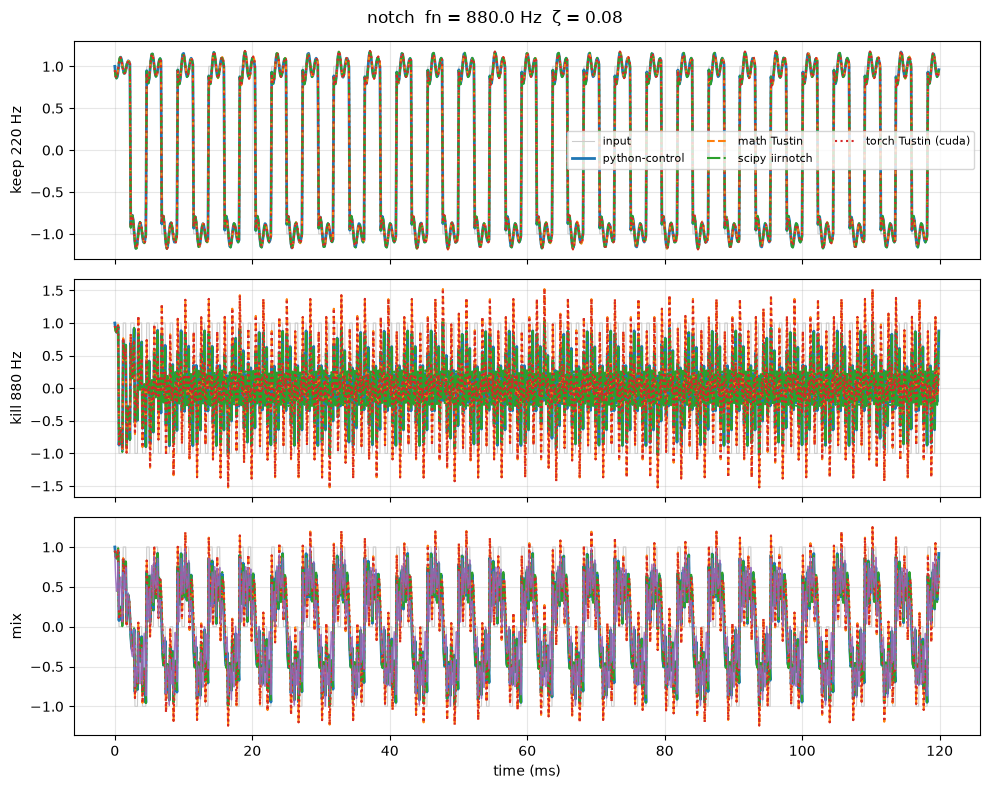

stack                rms keep   rms kill  kill/keep
python-control         0.9932     0.4436      0.447
math Tustin            0.9935     0.5857      0.590
scipy iirnotch         0.9931     0.4422      0.445
torch Tustin           0.9935     0.5857      0.590
torch FIR              0.9368     0.4328      0.462
math vs torch (mix) 3.091e-07


In [8]:
ms = t * 1e3
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
rows = [
    ("keep 220 Hz", u_keep, y_ct_keep, y_math_keep, y_sp_keep, y_th_keep_np),
    ("kill 880 Hz", u_kill, y_ct_kill, y_math_kill, y_sp_kill, y_th_kill_np),
    ("mix", u_mix, y_ct_mix, y_math_mix, y_sp_mix, y_th_mix_np),
]
for ax, (title, uu, *ys) in zip(axes, rows):
    ax.plot(ms, uu, color="0.8", lw=0.8, label="input")
    ax.plot(ms, ys[0], lw=2.0, label="python-control")
    ax.plot(ms, ys[1], ls="--", label="math Tustin")
    ax.plot(ms, ys[2], ls="-.", label="scipy iirnotch")
    ax.plot(ms, ys[3], ls=":", label=f"torch Tustin ({device})")
    if title == "mix":
        ax.plot(ms, y_fir_mix_np, lw=1.0, alpha=0.85, label="torch FIR")
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
axes[0].legend(ncol=3, fontsize=8)
axes[-1].set_xlabel("time (ms)")
fig.suptitle(f"notch  fn = {FN_HZ} Hz  ζ = {ZETA}")
fig.tight_layout()
plt.show()


def rms(x) -> float:
    a = np.asarray(x, dtype=np.float64)
    return float(np.sqrt(np.mean(a * a)))


print(f"{'stack':<18} {'rms keep':>10} {'rms kill':>10} {'kill/keep':>10}")
for name, yk, yr in [
    ("python-control", y_ct_keep, y_ct_kill),
    ("math Tustin", y_math_keep, y_math_kill),
    ("scipy iirnotch", y_sp_keep, y_sp_kill),
    ("torch Tustin", y_th_keep_np, y_th_kill_np),
    ("torch FIR", y_fir_keep_np, y_fir_kill_np),
]:
    rk, rr = rms(yk), rms(yr)
    print(f"{name:<18} {rk:10.4f} {rr:10.4f} {rr / max(rk, 1e-12):10.3f}")
print(f"math vs torch (mix) {max_abs(y_math_mix, y_th_mix_np):.3e}")

## Takeaways

- A notch is \(1 −\) the band-pass of notebook `11` (same \(\omega_n,\zeta\)).
- Forward Euler blows up at \(f_n/f_s \approx 0.11\); Tustin is the stable discrete copy of \(H(s)\).
- 220 Hz RMS stays large; 880 Hz RMS drops on control / Tustin / SciPy / FIR.
- FIR notch = unit impulse minus a band-pass kernel — another `conv1d` on `cuda`.
- Next (`14`): stop filtering excitations and start simulating **plants**.